In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Mounted at /content/drive


In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/iitmd_ba_2501164_FA-02"

df = pd.read_csv(f"{PROJECT_PATH}/cleaned_lending_club.csv")
df.shape


(14577, 88)

In [ ]:
df['default'].value_counts(normalize=True) * 100


,proportion
default,
0,79.069767
1,20.930233


In [ ]:
features = [
    'annual_inc',
    'dti',
    'fico_range_low',
    'loan_amnt',
    'int_rate',
    'delinq_2yrs'
]

X = df[features]
y = df['default']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coef_df


,Feature,Coefficient
4,int_rate,0.529325
3,loan_amnt,0.224404
1,dti,0.123460
5,delinq_2yrs,0.027291
2,fico_range_low,-0.195166
0,annual_inc,-0.205918


### Interpretation of Logistic Regression Coefficients

The coefficients of the logistic regression model indicate the direction and relative influence of each feature on the probability of default. Interest rate, loan amount, debt-to-income ratio, and past delinquencies increase default risk, while higher credit scores and higher annual income reduce default risk. The signs of the coefficients align with financial intuition, indicating a stable and interpretable model.


In [ ]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
cm


array([[3399,   60],
       [ 842,   73]])

In [ ]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.80      0.98      0.88      3459
           1       0.55      0.08      0.14       915

    accuracy                           0.79      4374
   macro avg       0.68      0.53      0.51      4374
weighted avg       0.75      0.79      0.73      4374



In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

roc_auc = roc_auc_score(y_test, y_pred_proba)
roc_auc


np.float64(0.6869195272647421)

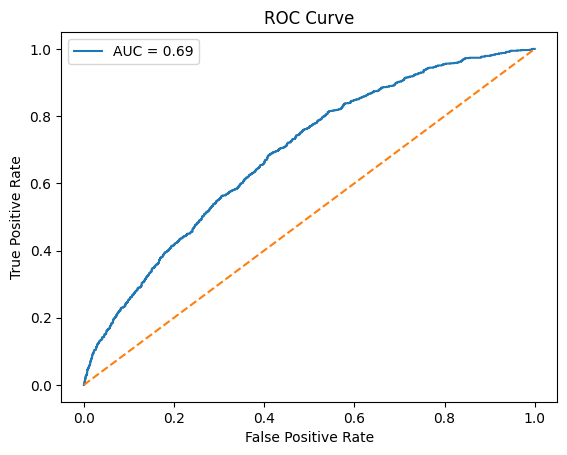

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


### Model Performance Interpretation

The logistic regression model achieves an overall accuracy of 79% and a ROC–AUC score of 0.687, indicating moderate discriminatory power between defaulters and non-defaulters.

While the model performs very well in identifying non-defaulters, recall for defaulters is relatively low. This behavior is expected in imbalanced credit risk datasets when using a default classification threshold of 0.5. The ROC–AUC score confirms that the model is able to rank borrowers by risk, even though threshold-based classification can be further optimized.


### Business Perspective

In credit risk applications, ranking borrowers by probability of default is often more important than raw classification accuracy. The model’s ROC–AUC score indicates that it can effectively differentiate higher-risk borrowers from lower-risk borrowers. By adjusting the probability threshold or using credit score cutoffs, lenders can trade off between approval rates and default risk according to business objectives.


In [ ]:
# Create credit score from probability of default
df_test = X_test.copy()
df_test['pd'] = y_pred_proba

# Scale PD to credit score (300–900)
df_test['credit_score'] = 900 - (df_test['pd'] * 600)

df_test[['pd', 'credit_score']].head()


,pd,credit_score
8988,0.350010,689.993774
14148,0.464843,621.093990
13191,0.118568,828.859338
6302,0.052766,868.340424
13101,0.073797,855.721957


In [ ]:
def risk_bucket(score):
    if score >= 750:
        return "Low Risk"
    elif score >= 650:
        return "Medium Risk"
    else:
        return "High Risk"

df_test['risk_segment'] = df_test['credit_score'].apply(risk_bucket)

df_test['risk_segment'].value_counts()


,count
risk_segment,
Low Risk,3089
Medium Risk,997
High Risk,288


### Risk Segmentation Results

Based on the derived credit scores, borrowers were segmented into low, medium, and high-risk categories. The majority of borrowers fall into the low-risk segment, indicating strong repayment capacity, while a smaller proportion is classified as high-risk. This segmentation enables lenders to design differentiated approval and pricing strategies aligned with borrower risk profiles.


In [ ]:
final_df = df.copy()
final_df['credit_score'] = 900 - (model.predict_proba(scaler.transform(df[features]))[:,1] * 600)

final_df['risk_segment'] = final_df['credit_score'].apply(
    lambda x: "Low Risk" if x >= 750 else ("Medium Risk" if x >= 650 else "High Risk")
)

final_df.to_csv("credit_scored_lending_club.csv", index=False)
